# Swimmer Velocity Estimation

Processes **`videos/under/Bottom_Free_1.MP4`** end-to-end:

1. **Probe** the video (FPS, resolution, duration) and preview sample frames  
2. **Detect** lane-rope markers (class 0) and the swimmer (class 1) in every frame using the trained YOLOv8 model  
3. **Filter** to frames where both markers and the swimmer are visible  
4. **Compute** the pixel-to-metre scale from the known physical marker separation and project the swimmer centroid onto the lane-rope line → position in metres from Marker 1  
5. **Estimate velocity** via a Savitzky–Golay derivative of the smoothed position signal  
6. **Visualise** detections, position, scale stability, and velocity/speed profiles  
7. **Export** an annotated video clip of the valid window


In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.signal import savgol_filter
from tqdm.notebook import tqdm
from ultralytics import YOLO


In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────

# Path to the source video
VIDEO_PATH          = "videos/under/Bottom_Free_1.MP4"

# Path to the trained YOLO weights
YOLO_MODEL_PATH     = "runs/detect/runs/detect/marker_detector/weights/best.pt"

# Physical distance between the two lane-rope markers (metres)
MARKER_REAL_DIST_M  = 5.0

# YOLO confidence threshold
YOLO_CONF           = 0.7

# Process every Nth frame (1 = every frame; increase to 2–3 to speed up detection)
FRAME_STEP          = 1

# Savitzky–Golay smoothing window for velocity estimation (must be odd, ≥ 5)
SG_WINDOW           = 21
SG_POLY             = 3


Video      : videos/under/Bottom_Free_1.MP4
Resolution : 3840 × 2160 px
FPS        : 119.880
Frames     : 6249
Duration   : 52.13 s  (0.87 min)


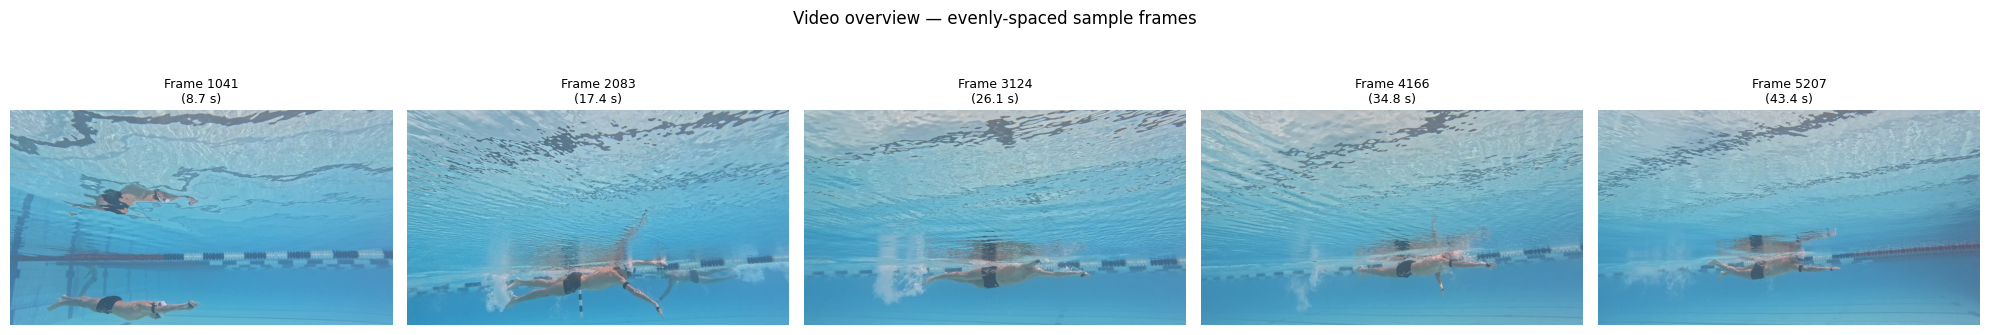

In [3]:
# ── Video probe & sample frames ───────────────────────────────────────────────
cap = cv2.VideoCapture(VIDEO_PATH)
assert cap.isOpened(), f"Cannot open video: {VIDEO_PATH}"

fps        = cap.get(cv2.CAP_PROP_FPS)
n_frames   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
img_w      = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
img_h      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
duration_s = n_frames / fps

print(f"Video      : {VIDEO_PATH}")
print(f"Resolution : {img_w} × {img_h} px")
print(f"FPS        : {fps:.3f}")
print(f"Frames     : {n_frames}")
print(f"Duration   : {duration_s:.2f} s  ({duration_s / 60:.2f} min)")

# Preview frames spread evenly across the video
N_PREVIEW = 5
fig, axes = plt.subplots(1, N_PREVIEW, figsize=(20, 4))
for i, ax in enumerate(axes):
    fidx = int(n_frames * (i + 1) / (N_PREVIEW + 1))
    cap.set(cv2.CAP_PROP_POS_FRAMES, fidx)
    ret, frame = cap.read()
    if ret:
        ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Frame {fidx}\n({fidx / fps:.1f} s)", fontsize=9)
    ax.axis("off")

fig.suptitle("Video overview — evenly-spaced sample frames", fontsize=12)
plt.tight_layout()
plt.show()
cap.release()


In [4]:
# ── Run YOLO on every frame (sequentially — most efficient for long videos) ───
det_model = YOLO(YOLO_MODEL_PATH)
records   = []   # one dict per processed frame

cap = cv2.VideoCapture(VIDEO_PATH)
fi  = 0

with tqdm(total=n_frames, desc="Running YOLO", unit="fr") as pbar:
    while True:
        ret, frame_bgr = cap.read()
        if not ret:
            break

        if fi % FRAME_STEP == 0:
            results                    = det_model(frame_bgr, conf=YOLO_CONF, verbose=False)[0]
            markers, swimmer, boxes_raw = [], None, []

            for box in results.boxes:
                cls          = int(box.cls)
                conf_val     = float(box.conf)
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                cx, cy       = (x1 + x2) / 2, (y1 + y2) / 2
                boxes_raw.append((cls, conf_val, x1, y1, x2, y2, cx, cy))
                if cls == 0:
                    markers.append((cx, cy))
                elif cls == 1:
                    swimmer = (cx, cy)

            records.append({
                "frame_idx": fi,
                "time_s"   : fi / fps,
                "markers"  : markers,
                "swimmer"  : swimmer,
                "boxes_raw": boxes_raw,
            })

        fi  += 1
        pbar.update(1)

cap.release()

# ── Detection summary ─────────────────────────────────────────────────────────
total  = len(records)
n_2m   = sum(1 for r in records if len(r["markers"]) >= 2)
n_swim = sum(1 for r in records if r["swimmer"] is not None)
n_both = sum(1 for r in records if len(r["markers"]) >= 2 and r["swimmer"] is not None)

print(f"Frames processed   : {total}")
print(f"  ≥2 markers       : {n_2m}  ({100 * n_2m  / total:.1f} %)")
print(f"  Swimmer detected : {n_swim}  ({100 * n_swim / total:.1f} %)")
print(f"  Both (valid)     : {n_both}  ({100 * n_both / total:.1f} %)")


Running YOLO:   0%|          | 0/6249 [00:00<?, ?fr/s]

Frames processed   : 6249
  ≥2 markers       : 1383  (22.1 %)
  Swimmer detected : 4239  (67.8 %)
  Both (valid)     : 1348  (21.6 %)


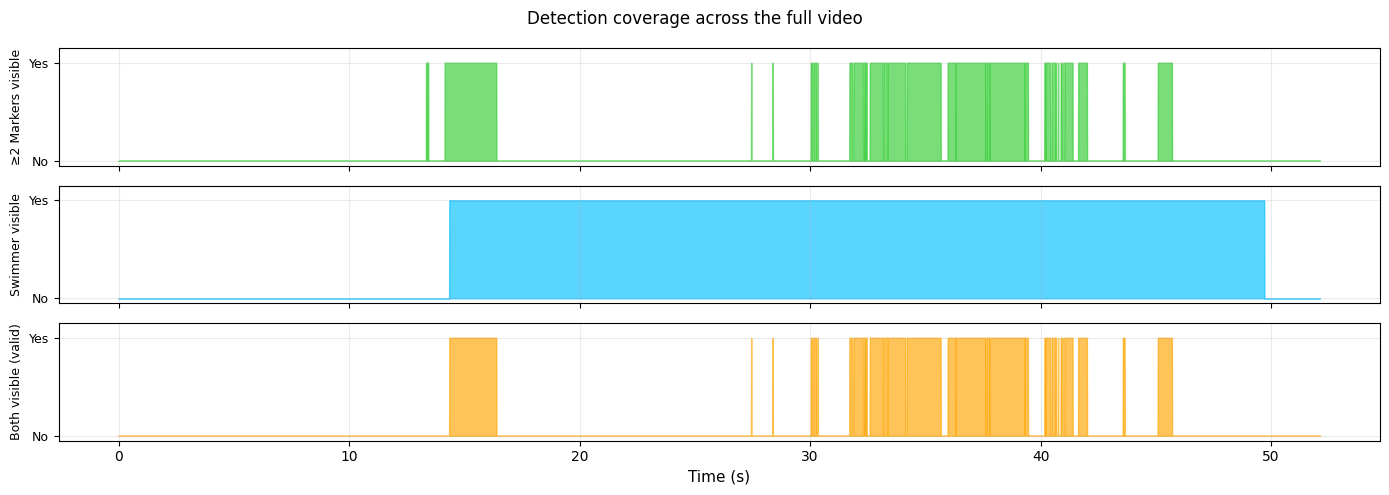

In [5]:
# ── Detection coverage across the video ──────────────────────────────────────
frame_times = np.array([r["time_s"]  for r in records])
has_2m      = np.array([len(r["markers"]) >= 2        for r in records], dtype=float)
has_swim    = np.array([r["swimmer"] is not None       for r in records], dtype=float)
has_both    = has_2m * has_swim

fig, axes = plt.subplots(3, 1, figsize=(14, 5), sharex=True)
for ax, data, label, color in zip(
    axes,
    [has_2m, has_swim, has_both],
    ["≥2 Markers visible", "Swimmer visible", "Both visible (valid)"],
    ["limegreen", "deepskyblue", "orange"],
):
    ax.fill_between(frame_times, data, alpha=0.65, color=color)
    ax.set_ylim(-0.05, 1.15)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["No", "Yes"], fontsize=9)
    ax.set_ylabel(label, fontsize=9)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel("Time (s)", fontsize=11)
fig.suptitle("Detection coverage across the full video", fontsize=12)
plt.tight_layout()
plt.show()


In [6]:
# ── Filter to valid frames & compute per-frame scale + swimmer position ───────
valid = []

for r in records:
    if len(r["markers"]) < 2 or r["swimmer"] is None:
        continue

    # Sort markers left-to-right so A is always the leftmost
    mc_sorted = sorted(r["markers"][:2], key=lambda p: p[0])
    A = np.array(mc_sorted[0])
    B = np.array(mc_sorted[1])
    S = np.array(r["swimmer"])

    AB        = B - A
    AB_len_px = float(np.linalg.norm(AB))
    if AB_len_px < 1.0:        # degenerate detection — skip
        continue

    AB_unit  = AB / AB_len_px
    px_per_m = AB_len_px / MARKER_REAL_DIST_M

    # Project swimmer onto the lane-rope line: t ∈ [0,1] → between markers
    t_param = np.dot(S - A, AB_unit) / AB_len_px
    # Physical position along the rope from Marker 1 (can exceed MARKER_REAL_DIST_M)
    pos_m   = t_param * MARKER_REAL_DIST_M

    valid.append({
        "frame_idx": r["frame_idx"],
        "time_s"   : r["time_s"],
        "px_per_m" : px_per_m,
        "pos_m"    : pos_m,
        "t_param"  : t_param,
        "A"        : A,
        "B"        : B,
        "S"        : S,
        "boxes_raw": r["boxes_raw"],
    })

assert valid, "No valid frames found — try lowering YOLO_CONF or check the video path."

t0 = valid[0]["time_s"]
t1 = valid[-1]["time_s"]
all_px_per_m = [v["px_per_m"] for v in valid]
all_pos_m    = [v["pos_m"]    for v in valid]

print(f"Valid frames          : {len(valid)}  ({100 * len(valid) / len(records):.1f}% of processed)")
print(f"Time window           : {t0:.2f} s – {t1:.2f} s  ({t1 - t0:.2f} s)")
print(f"px/m  mean ± std      : {np.mean(all_px_per_m):.2f} ± {np.std(all_px_per_m):.2f}")
print(f"Position range        : {min(all_pos_m):.2f} m – {max(all_pos_m):.2f} m")


Valid frames          : 1348  (21.6% of processed)
Time window           : 14.35 s – 45.70 s  (31.35 s)
px/m  mean ± std      : 306.79 ± 125.55
Position range        : 1.38 m – 7.30 m


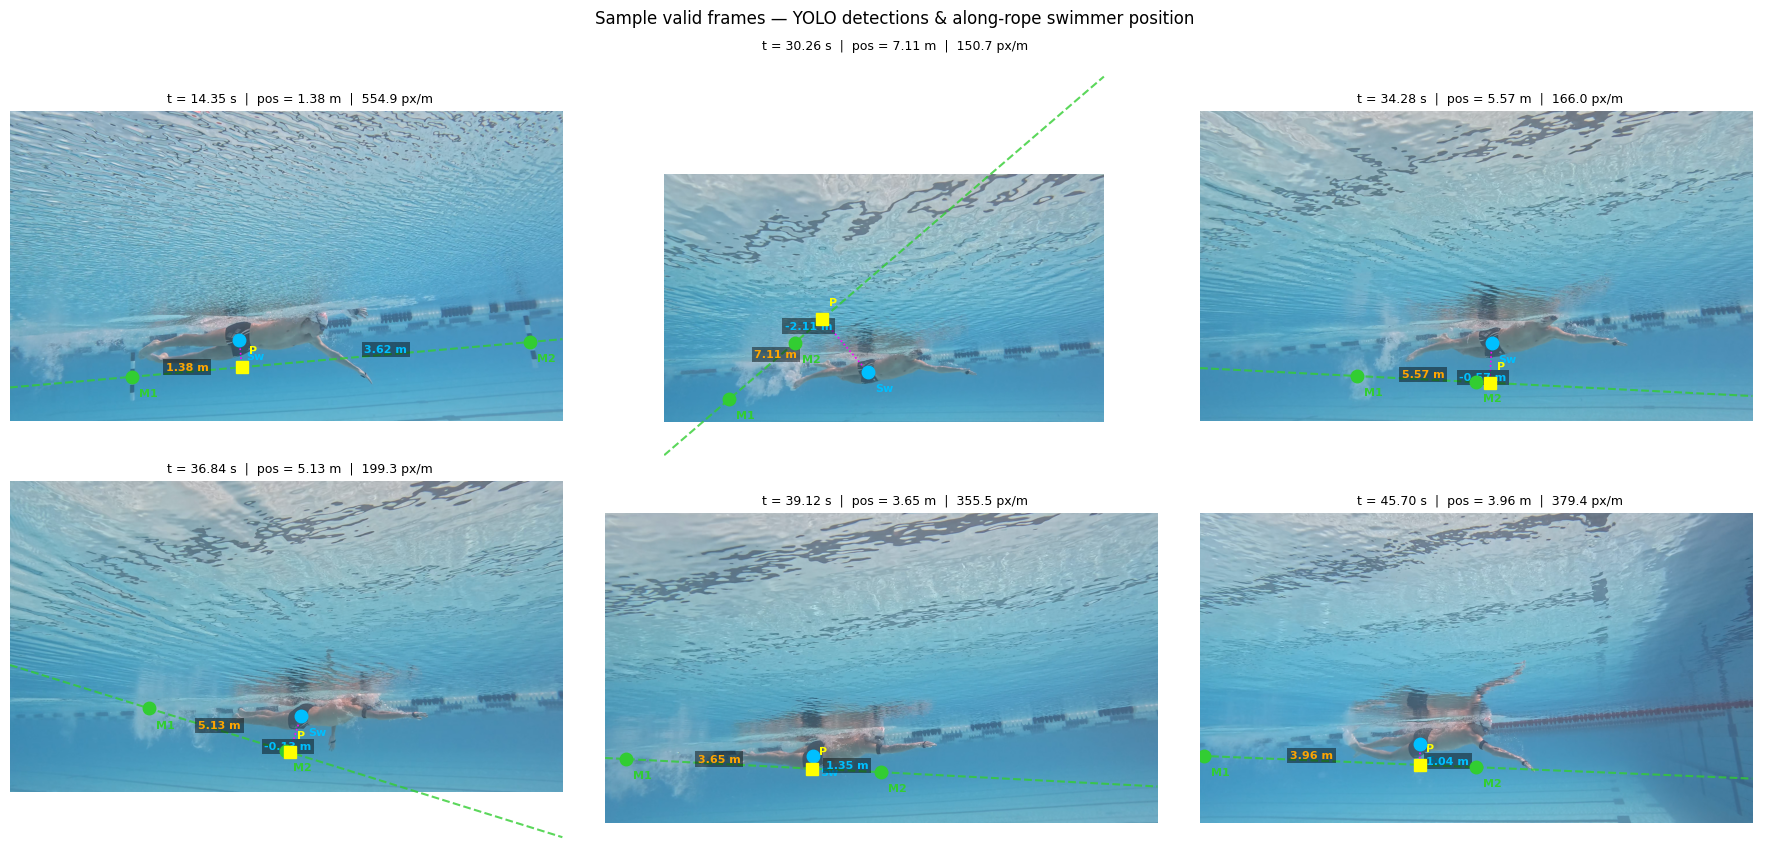

In [7]:
# ── Sample valid-frame visualisations (2 × 3 grid) ───────────────────────────
N_SAMPLE = 6
sample_vis = [valid[int(i * (len(valid) - 1) / (N_SAMPLE - 1))] for i in range(N_SAMPLE)]

cap = cv2.VideoCapture(VIDEO_PATH)
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

for ax, vd in zip(axes, sample_vis):
    cap.set(cv2.CAP_PROP_POS_FRAMES, vd["frame_idx"])
    ret, frame_bgr = cap.read()
    if not ret:
        ax.axis("off")
        continue
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    ax.imshow(frame_rgb)

    A, B, S = vd["A"], vd["B"], vd["S"]
    AB      = B - A
    t       = vd["t_param"]
    P       = A + t * AB           # projected swimmer position on the rope

    # Lane-rope baseline extended to image edges
    denom = AB[0] if abs(AB[0]) > 1 else 1.0
    t_lo, t_hi = sorted([(0 - A[0]) / denom, (img_w - A[0]) / denom])
    ls, le = A + t_lo * AB, A + t_hi * AB
    ax.plot([ls[0], le[0]], [ls[1], le[1]],
            color="limegreen", linewidth=1.5, linestyle="--", alpha=0.8)

    # Markers, swimmer, projection
    ax.plot(*A, "o", color="limegreen",   markersize=9, zorder=5)
    ax.plot(*B, "o", color="limegreen",   markersize=9, zorder=5)
    ax.plot(*S, "o", color="deepskyblue", markersize=9, zorder=5)
    ax.plot([S[0], P[0]], [S[1], P[1]], color="magenta", linewidth=1.2, linestyle=":")
    ax.plot(*P, "s", color="yellow",      markersize=8, zorder=6)

    # Labels
    for pt, label, col, dy in [
        (A, "M1", "limegreen",   -14),
        (B, "M2", "limegreen",   -14),
        (S, "Sw", "deepskyblue", -14),
        (P, "P",  "yellow",      +10),
    ]:
        ax.annotate(label, pt, textcoords="offset points", xytext=(5, dy),
                    color=col, fontsize=8, fontweight="bold")

    # A→P and P→B distances
    dist_A_m = t * MARKER_REAL_DIST_M
    dist_B_m = (1 - t) * MARKER_REAL_DIST_M
    mid_AP   = (A + P) / 2
    mid_PB   = (P + B) / 2
    for mid, dist, col in [(mid_AP, dist_A_m, "orange"), (mid_PB, dist_B_m, "deepskyblue")]:
        ax.text(mid[0], mid[1] - 14, f"{dist:.2f} m",
                color=col, fontsize=8, fontweight="bold", ha="center",
                bbox=dict(facecolor="black", alpha=0.45, pad=2, edgecolor="none"))

    ax.set_title(
        f"t = {vd['time_s']:.2f} s  |  pos = {vd['pos_m']:.2f} m  |  {vd['px_per_m']:.1f} px/m",
        fontsize=9
    )
    ax.axis("off")

cap.release()
fig.suptitle("Sample valid frames — YOLO detections & along-rope swimmer position", fontsize=12)
plt.tight_layout()
plt.show()


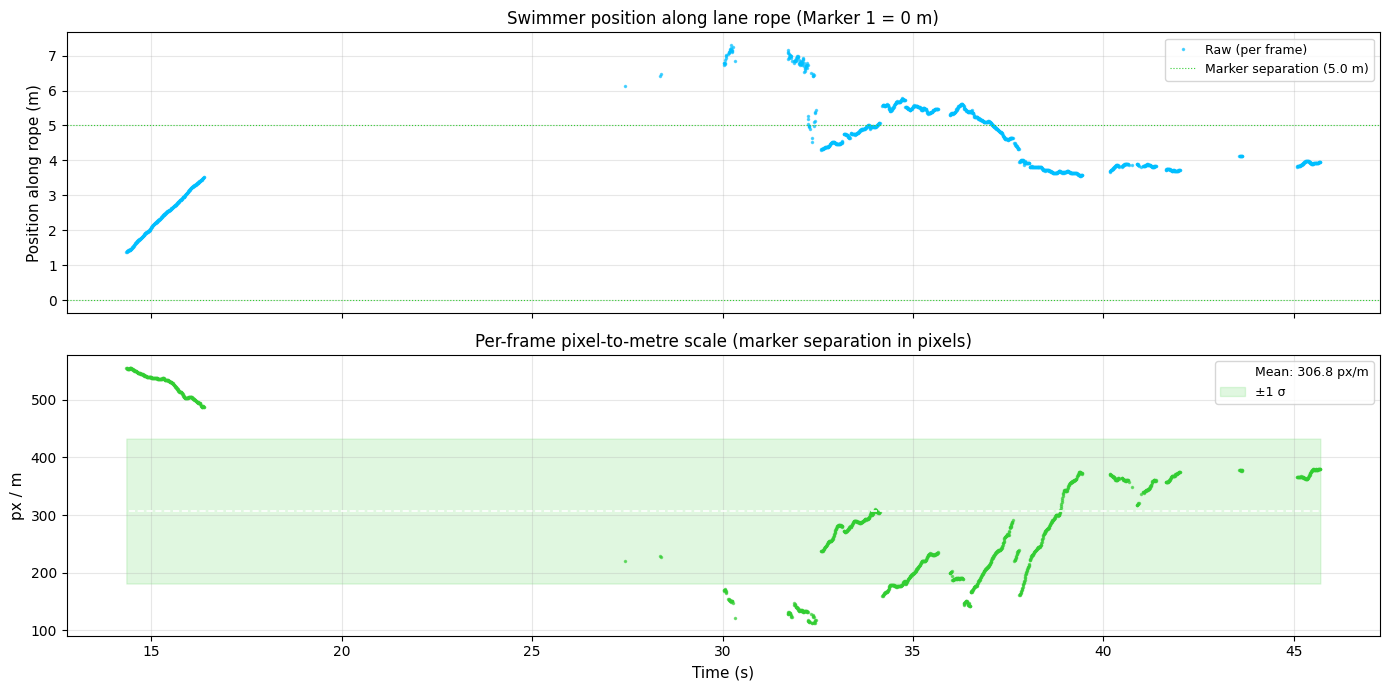

In [8]:
# ── Position along the rope & pixel-to-metre scale over time ─────────────────
times    = np.array([v["time_s"]  for v in valid])
pos_raw  = np.array([v["pos_m"]   for v in valid])
scales   = np.array([v["px_per_m"] for v in valid])

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# ── Position ──
axes[0].plot(times, pos_raw, ".", markersize=3, color="deepskyblue", alpha=0.6,
             label="Raw (per frame)")
axes[0].axhline(0,                  color="limegreen",   linewidth=0.8, linestyle=":")
axes[0].axhline(MARKER_REAL_DIST_M, color="limegreen",   linewidth=0.8, linestyle=":",
                label=f"Marker separation ({MARKER_REAL_DIST_M} m)")
axes[0].set_ylabel("Position along rope (m)", fontsize=11)
axes[0].set_title("Swimmer position along lane rope (Marker 1 = 0 m)", fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# ── Scale stability ──
mean_scale = np.mean(scales)
axes[1].plot(times, scales, ".", markersize=3, color="limegreen", alpha=0.6)
axes[1].axhline(mean_scale, color="white", linewidth=1.2, linestyle="--",
                label=f"Mean: {mean_scale:.1f} px/m")
axes[1].fill_between(times,
                     mean_scale - np.std(scales),
                     mean_scale + np.std(scales),
                     alpha=0.15, color="limegreen", label="±1 σ")
axes[1].set_ylabel("px / m", fontsize=11)
axes[1].set_xlabel("Time (s)", fontsize=11)
axes[1].set_title("Per-frame pixel-to-metre scale (marker separation in pixels)", fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [9]:
# ── Velocity estimation via Savitzky–Golay derivative ────────────────────────
#
# Strategy:
#   1. Interpolate the (possibly non-uniform / gapped) position signal onto a
#      uniform time grid at the native frame rate.
#   2. Smooth with a Savitzky–Golay filter (zero-phase, polynomial fit).
#   3. Differentiate the same filter in one pass (deriv=1) to get velocity.
#   4. Map the smoothed velocity back onto the original valid-frame timestamps.

dt_u    = FRAME_STEP / fps                              # uniform time step (s)
times_u = np.arange(times[0], times[-1] + dt_u * 0.5, dt_u)
pos_u   = np.interp(times_u, times, pos_raw)           # fill detection gaps

# Clamp SG window to the signal length (must be odd and > poly order)
sg_win = min(SG_WINDOW, len(pos_u))
if sg_win % 2 == 0:
    sg_win -= 1
sg_win = max(sg_win, SG_POLY + 2 + (SG_POLY + 2) % 2 - 1)   # odd lower bound

pos_smooth  = savgol_filter(pos_u, sg_win, SG_POLY)
vel_smooth_u = savgol_filter(pos_u, sg_win, SG_POLY, deriv=1, delta=dt_u)  # m/s

# Interpolate back onto the original valid-frame timestamps
vel_at_valid = np.interp(times, times_u, vel_smooth_u)
spd_at_valid = np.abs(vel_at_valid)

print(f"SG window (frames)  : {sg_win}  (~{sg_win * dt_u:.3f} s)")
print(f"Peak speed          : {spd_at_valid.max():.4f} m/s  ({spd_at_valid.max() * 3.6:.3f} km/h)")
print(f"Mean |speed|        : {spd_at_valid.mean():.4f} m/s  ({spd_at_valid.mean() * 3.6:.3f} km/h)")
print(f"Max positive vel.   : {vel_at_valid.max():.4f} m/s  (toward Marker 2)")
print(f"Min negative vel.   : {vel_at_valid.min():.4f} m/s  (toward Marker 1)")


SG window (frames)  : 21  (~0.175 s)
Peak speed          : 30.7962 m/s  (110.866 km/h)
Mean |speed|        : 1.0595 m/s  (3.814 km/h)
Max positive vel.   : 13.8542 m/s  (toward Marker 2)
Min negative vel.   : -30.7962 m/s  (toward Marker 1)


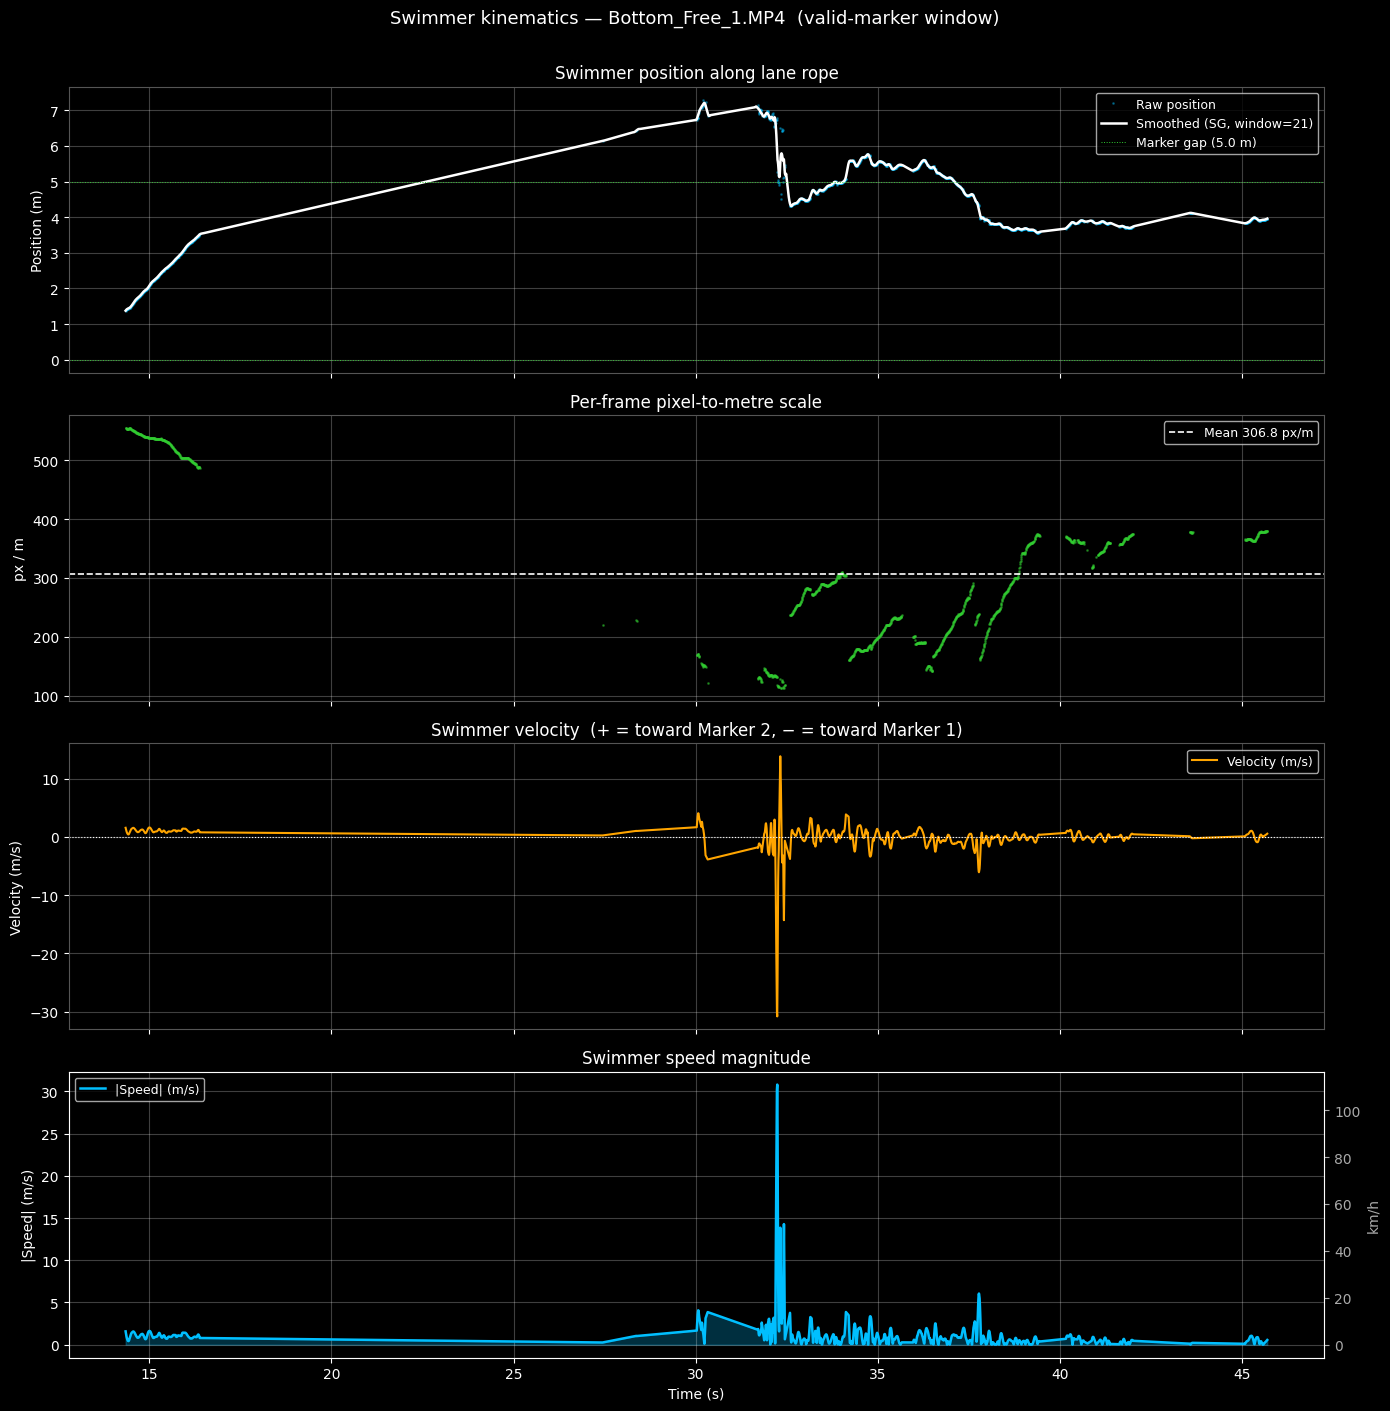

In [10]:
# ── Velocity & speed multi-panel plot ────────────────────────────────────────
with plt.style.context("dark_background"):
    fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

    # [0] Raw + smoothed position
    axes[0].plot(times,   pos_raw,    ".", markersize=2, color="deepskyblue",
                 alpha=0.35, label="Raw position")
    axes[0].plot(times_u, pos_smooth, "-", linewidth=1.8, color="white",
                 label=f"Smoothed (SG, window={sg_win})")
    axes[0].axhline(0,                  color="limegreen", linewidth=0.7, linestyle=":")
    axes[0].axhline(MARKER_REAL_DIST_M, color="limegreen", linewidth=0.7, linestyle=":",
                    label=f"Marker gap ({MARKER_REAL_DIST_M} m)")
    axes[0].set_ylabel("Position (m)")
    axes[0].set_title("Swimmer position along lane rope")
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.25)

    # [1] Pixel-to-metre scale
    axes[1].plot(times, scales, ".", markersize=2, color="limegreen", alpha=0.45)
    axes[1].axhline(np.mean(scales), color="white", linewidth=1.2, linestyle="--",
                    label=f"Mean {np.mean(scales):.1f} px/m")
    axes[1].set_ylabel("px / m")
    axes[1].set_title("Per-frame pixel-to-metre scale")
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.25)

    # [2] Signed velocity
    axes[2].plot(times, vel_at_valid, "-", linewidth=1.5, color="orange",
                 label="Velocity (m/s)")
    axes[2].axhline(0, color="white", linewidth=0.8, linestyle=":")
    axes[2].set_ylabel("Velocity (m/s)")
    axes[2].set_title("Swimmer velocity  (+ = toward Marker 2, − = toward Marker 1)")
    axes[2].legend(fontsize=9)
    axes[2].grid(alpha=0.25)

    # [3] Speed magnitude with twin km/h axis
    axes[3].fill_between(times, spd_at_valid, alpha=0.25, color="deepskyblue")
    axes[3].plot(times, spd_at_valid, "-", linewidth=1.8, color="deepskyblue",
                 label="|Speed| (m/s)")

    ax3b = axes[3].twinx()
    # Keep km/h range in sync
    ms_lo, ms_hi = axes[3].get_ylim()
    ax3b.set_ylim(ms_lo * 3.6, ms_hi * 3.6)
    ax3b.set_ylabel("km/h", fontsize=10, color="#aaaaaa")
    ax3b.tick_params(colors="#aaaaaa")

    axes[3].set_ylabel("|Speed| (m/s)")
    axes[3].set_xlabel("Time (s)")
    axes[3].set_title("Swimmer speed magnitude")
    axes[3].legend(fontsize=9, loc="upper left")
    axes[3].grid(alpha=0.25)

    for ax in axes:
        for spine in ax.spines.values():
            spine.set_edgecolor("#555555")

    fig.suptitle("Swimmer kinematics — Bottom_Free_1.MP4  (valid-marker window)",
                 fontsize=13, y=1.005)
    plt.tight_layout()
    plt.show()


In [11]:
# ── Export annotated video clip (valid-marker window) ─────────────────────────
# Writes every frame between the first and last valid detection.
# Frames with full detections get overlaid annotations; others pass through raw.

OUTPUT_VIDEO = "swimmer_velocity_annotated.mp4"

start_fi = valid[0]["frame_idx"]
end_fi   = valid[-1]["frame_idx"]
n_out    = end_fi - start_fi + 1

# Fast-lookup dicts keyed by frame index
valid_lookup = {v["frame_idx"]: v                     for v in valid}
vel_lookup   = {valid[i]["frame_idx"]: vel_at_valid[i] for i in range(len(valid))}

# Running peak speed so we can display it live on each frame
peak_speed_so_far = 0.0

# ── Helper: semi-transparent filled rectangle ──────────────────────────────
def draw_alpha_rect(img, x1, y1, x2, y2, color=(0, 0, 0), alpha=0.55):
    sub = img[y1:y2, x1:x2]
    overlay = sub.copy()
    cv2.rectangle(overlay, (0, 0), (x2 - x1, y2 - y1), color, -1)
    cv2.addWeighted(overlay, alpha, sub, 1 - alpha, 0, sub)
    img[y1:y2, x1:x2] = sub

# ── Helper: outlined text for readability on any background ───────────────
def put_text(img, text, org, scale=0.65, color=(255, 255, 255), thickness=2):
    cv2.putText(img, text, org, cv2.FONT_HERSHEY_SIMPLEX, scale,
                (0, 0, 0), thickness + 2, cv2.LINE_AA)   # black outline
    cv2.putText(img, text, org, cv2.FONT_HERSHEY_SIMPLEX, scale,
                color, thickness, cv2.LINE_AA)

cap    = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, start_fi)
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out    = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps, (img_w, img_h))

LINE_H  = 28    # pixels between HUD lines
PAD     = 8     # panel padding
FONT_S  = 0.65  # main HUD font scale
FONT_SM = 0.55  # small label font scale

with tqdm(total=n_out, desc="Writing annotated video", unit="fr") as pbar:
    for fi in range(start_fi, end_fi + 1):
        ret, frame_bgr = cap.read()
        if not ret:
            break

        vd = valid_lookup.get(fi)
        if vd is not None:
            A, B, S = vd["A"], vd["B"], vd["S"]
            AB      = B - A
            t       = vd["t_param"]
            P       = A + t * AB
            vel     = vel_lookup.get(fi, 0.0)
            speed   = abs(vel)
            direction = "-> M2" if vel >= 0 else "<- M1"

            peak_speed_so_far = max(peak_speed_so_far, speed)

            dist_A_m = t * MARKER_REAL_DIST_M
            dist_B_m = (1 - t) * MARKER_REAL_DIST_M

            # ── Geometric overlays ─────────────────────────────────────
            # Lane-rope baseline
            cv2.line(frame_bgr, tuple(A.astype(int)), tuple(B.astype(int)),
                     (0, 255, 0), 2, cv2.LINE_AA)
            # A→P segment (orange)
            cv2.line(frame_bgr, tuple(A.astype(int)), tuple(P.astype(int)),
                     (0, 165, 255), 3, cv2.LINE_AA)
            # P→B segment (yellow)
            cv2.line(frame_bgr, tuple(P.astype(int)), tuple(B.astype(int)),
                     (0, 255, 255), 3, cv2.LINE_AA)
            # Swimmer → P projection line (magenta)
            cv2.line(frame_bgr, tuple(S.astype(int)), tuple(P.astype(int)),
                     (255, 0, 255), 1, cv2.LINE_AA)
            # Markers
            cv2.circle(frame_bgr, tuple(A.astype(int)), 10, (0, 255, 0), -1)
            cv2.circle(frame_bgr, tuple(B.astype(int)), 10, (0, 255, 0), -1)
            # Swimmer centroid
            cv2.circle(frame_bgr, tuple(S.astype(int)), 10, (0, 165, 255), -1)
            # Projected point P (cyan square)
            pi = P.astype(int)
            cv2.rectangle(frame_bgr,
                          (pi[0] - 6, pi[1] - 6), (pi[0] + 6, pi[1] + 6),
                          (0, 255, 255), 2)

            # ── Inline geometric labels ────────────────────────────────
            put_text(frame_bgr, "M1", (int(A[0]) + 12, int(A[1]) - 10),
                     FONT_SM, (0, 255, 0))
            put_text(frame_bgr, "M2", (int(B[0]) + 12, int(B[1]) - 10),
                     FONT_SM, (0, 255, 0))
            put_text(frame_bgr, "Sw", (int(S[0]) + 12, int(S[1]) - 10),
                     FONT_SM, (0, 165, 255))
            put_text(frame_bgr, "P", (pi[0] + 10, pi[1] + 6),
                     FONT_SM, (0, 255, 255))

            # Along-rope distance labels at segment midpoints
            mid_AP = ((A + P) / 2).astype(int)
            mid_PB = ((P + B) / 2).astype(int)
            put_text(frame_bgr, f"{dist_A_m:.2f}m",
                     (mid_AP[0] - 20, mid_AP[1] - 14), FONT_SM, (0, 165, 255))
            put_text(frame_bgr, f"{dist_B_m:.2f}m",
                     (mid_PB[0] - 20, mid_PB[1] - 14), FONT_SM, (0, 255, 255))

            # ── HUD panel (top-left, semi-transparent) ────────────────
            hud_lines = [
                ("Frame",    f"{fi}  |  {vd['time_s']:.2f} s",
                 (200, 200, 200)),
                ("Position", f"{vd['pos_m']:.3f} m from M1  |  {dist_B_m:.3f} m to M2",
                 (0, 210, 255)),
                ("Velocity", f"{vel:+.3f} m/s  {direction}",
                 (0, 200, 80) if vel >= 0 else (80, 80, 255)),
                ("Speed",    f"{speed:.4f} m/s  ({speed * 3.6:.3f} km/h)",
                 (255, 165, 0)),
                ("Peak spd", f"{peak_speed_so_far:.4f} m/s  "
                             f"({peak_speed_so_far * 3.6:.3f} km/h)",
                 (0, 200, 255)),
                ("Scale",    f"{vd['px_per_m']:.1f} px/m  |  "
                             f"{100 / vd['px_per_m']:.4f} cm/px",
                 (180, 255, 180)),
            ]

            panel_w = 490
            panel_h = len(hud_lines) * LINE_H + PAD * 2
            draw_alpha_rect(frame_bgr, 6, 6, 6 + panel_w, 6 + panel_h,
                            color=(0, 0, 0), alpha=0.60)

            for row, (key, val, col) in enumerate(hud_lines):
                y = 6 + PAD + (row + 1) * LINE_H - 6
                put_text(frame_bgr, f"{key}:", (14, y), FONT_S, (180, 180, 180))
                put_text(frame_bgr, val, (140, y), FONT_S, col)

            # ── Speed bar (top of screen, below HUD panel) ────────────
            bar_margin  = 20
            bar_y0      = 6 + panel_h + 10
            bar_y1      = bar_y0 + 18
            bar_total_w = img_w - 2 * bar_margin
            max_speed   = max(float(spd_at_valid.max()), 1e-6)
            bar_fill_w  = int(bar_total_w * min(speed / max_speed, 1.0))

            draw_alpha_rect(frame_bgr,
                            bar_margin, bar_y0 - 4,
                            bar_margin + bar_total_w, bar_y1 + 4,
                            color=(20, 20, 20), alpha=0.65)
            cv2.rectangle(frame_bgr,
                          (bar_margin, bar_y0),
                          (bar_margin + bar_total_w, bar_y1),
                          (70, 70, 70), -1)
            if bar_fill_w > 0:
                frac    = min(speed / max_speed, 1.0)
                bar_col = (0, int(255 * (1 - frac)), int(255 * frac))  # green→red
                cv2.rectangle(frame_bgr,
                              (bar_margin, bar_y0),
                              (bar_margin + bar_fill_w, bar_y1),
                              bar_col, -1)

            bar_label = f"Speed: {speed:.3f} m/s  ({speed * 3.6:.2f} km/h)"
            put_text(frame_bgr, bar_label,
                     (bar_margin + bar_total_w // 2 - 100, bar_y0 - 6),
                     0.55, (255, 255, 255))

        out.write(frame_bgr)
        pbar.update(1)

cap.release()
out.release()
print(f"Saved  ->  {OUTPUT_VIDEO}")
print(f"Clip   :  {n_out} frames  ({n_out / fps:.1f} s)  @  {fps:.1f} fps")


Writing annotated video:   0%|          | 0/3759 [00:00<?, ?fr/s]

Saved  ->  swimmer_velocity_annotated.mp4
Clip   :  3759 frames  (31.4 s)  @  119.9 fps
